In [1]:
import pandas
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import h5py

import chroma

plt.style.use("chroma.paper")

In [6]:
total_energy = {}
potential_energy = {}
for condition in ["control", "complete", "lamina", "nuclear-bodies"]:
    total_energy[condition] = []
    potential_energy[condition] = []

    for replica in range(1, 31):
        df = pandas.read_csv(
            f"/scratch/mm146/Polarization/2_IMR-90_hg38/4_single-chr-simulation/{condition}/{replica}/statistics.txt",
            delimiter=",",
            skiprows=2,
            names=[
                "step",
                "rg",
                "total_energy",
                "potential_energy",
                "kinetic_energy",
                "temperature",
            ],
        )
        total_energy[condition].extend(df["total_energy"].to_numpy())
        potential_energy[condition].extend(
            df["potential_energy"].to_numpy()
        )

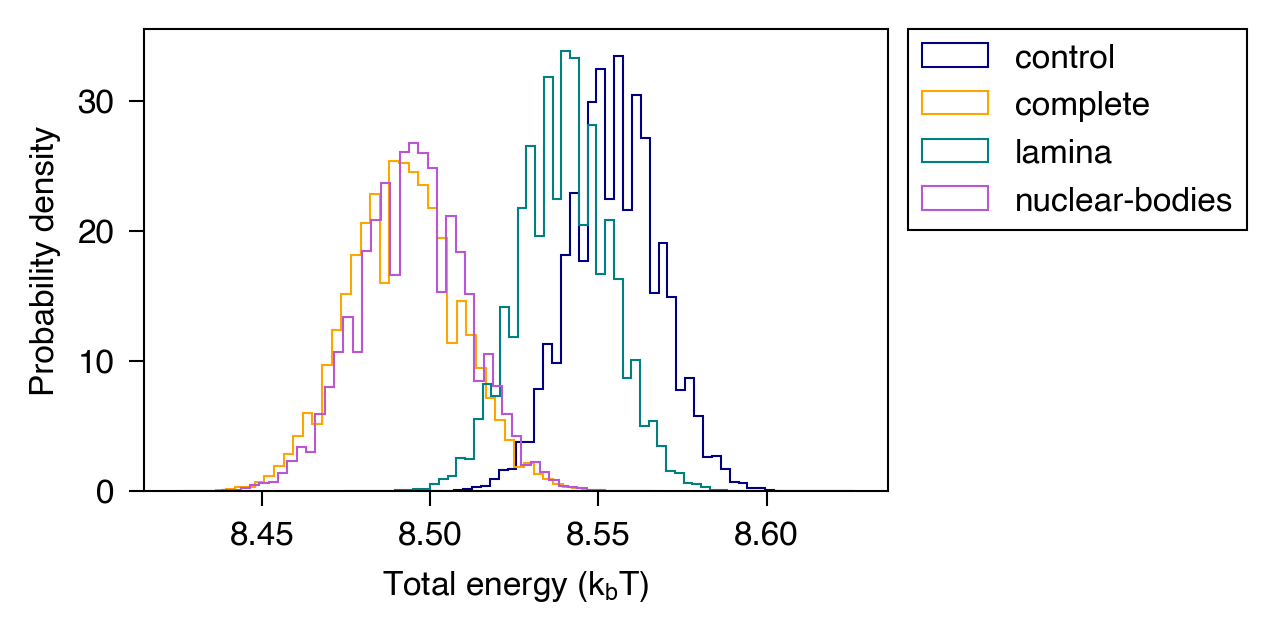

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3.2, 2))

for condition in total_energy.keys():
    ax.hist(
        total_energy[condition],
        bins=50,
        density=True,
        histtype="step",
        label=condition,
    )

ax.set_xlabel(r"Total energy ($k_B$T)")
ax.set_ylabel("Probability density")
ax.legend(bbox_to_anchor=(1.005, 1.036), loc="upper left")

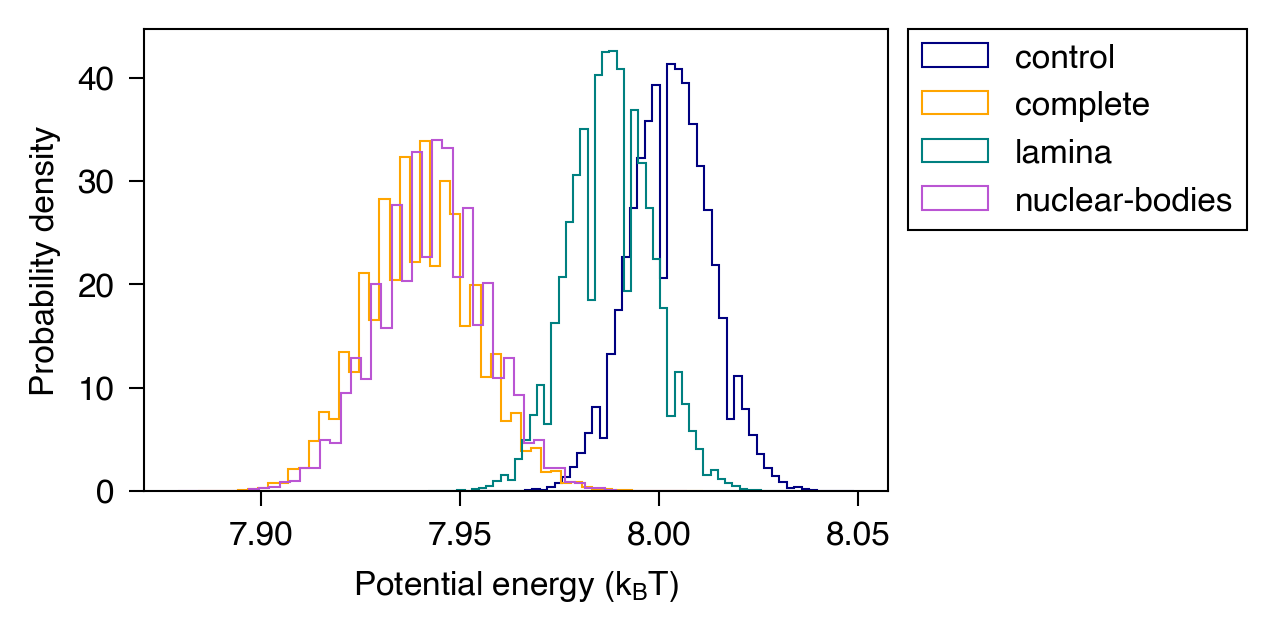

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(3.2, 2))

for condition in potential_energy.keys():
    ax.hist(
        potential_energy[condition],
        bins=50,
        density=True,
        histtype="step",
        label=condition,
    )

ax.set_xlabel(r"Potential energy ($k_B$T)")
ax.set_ylabel("Probability density")
ax.legend(bbox_to_anchor=(1.005, 1.036), loc="upper left")

# Plotting contact energies

In [5]:
num_chr = "one"
condition = "complete"
replica = 1
chromosome = 10

In [6]:
energies = {}
with h5py.File(
    f"data/{num_chr}/{condition}/contact-energies-chr{chromosome}-replica{replica}.h5",
    "r",
) as f:
    for key in f.keys():
        energies[key] = f[key][()]

Text(0, 0.5, 'Energy ($k_B$T)')

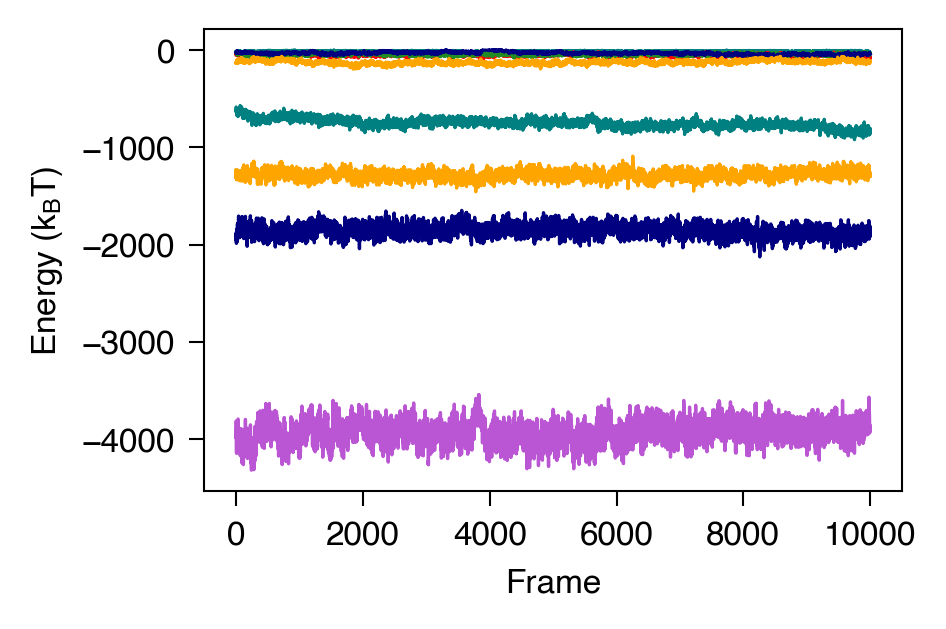

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
for key in energies.keys():
    ax.plot(
        energies[key],
        label=key,
    )
ax.set_xlabel("Frame")
ax.set_ylabel("Energy ($k_B$T)")

In [3]:
conditions = [
    "control",
    "complete",
    "lamina",
    "nucleolus",
]

In [5]:
energies_per_condition = {}
for condition in conditions:
    energies_per_condition[condition] = {}
    for replica in range(1, 32 + 1):
        with h5py.File(
            f"/scratch/mm146/Polarization/3_IMR-90_hg38_fields-nb/4_analysis/energies/data/{condition}/contact-energies-replica{replica}.h5",
            "r",
        ) as f:
            for key in f.keys():
                if key not in energies_per_condition[condition]:
                    energies_per_condition[condition][key] = np.array(
                        []
                    )
                energies_per_condition[condition][key] = (
                    np.concatenate(
                        (
                            energies_per_condition[condition][key],
                            f[key][()],
                        ),
                        axis=0,
                    )
                )
            energies_per_condition[condition]["all"] = np.sum(
                np.array(
                    [
                        energies_per_condition[condition][k]
                        for k in energies_per_condition[condition]
                        if k != "all"
                    ]
                ),
                axis=0,
            )

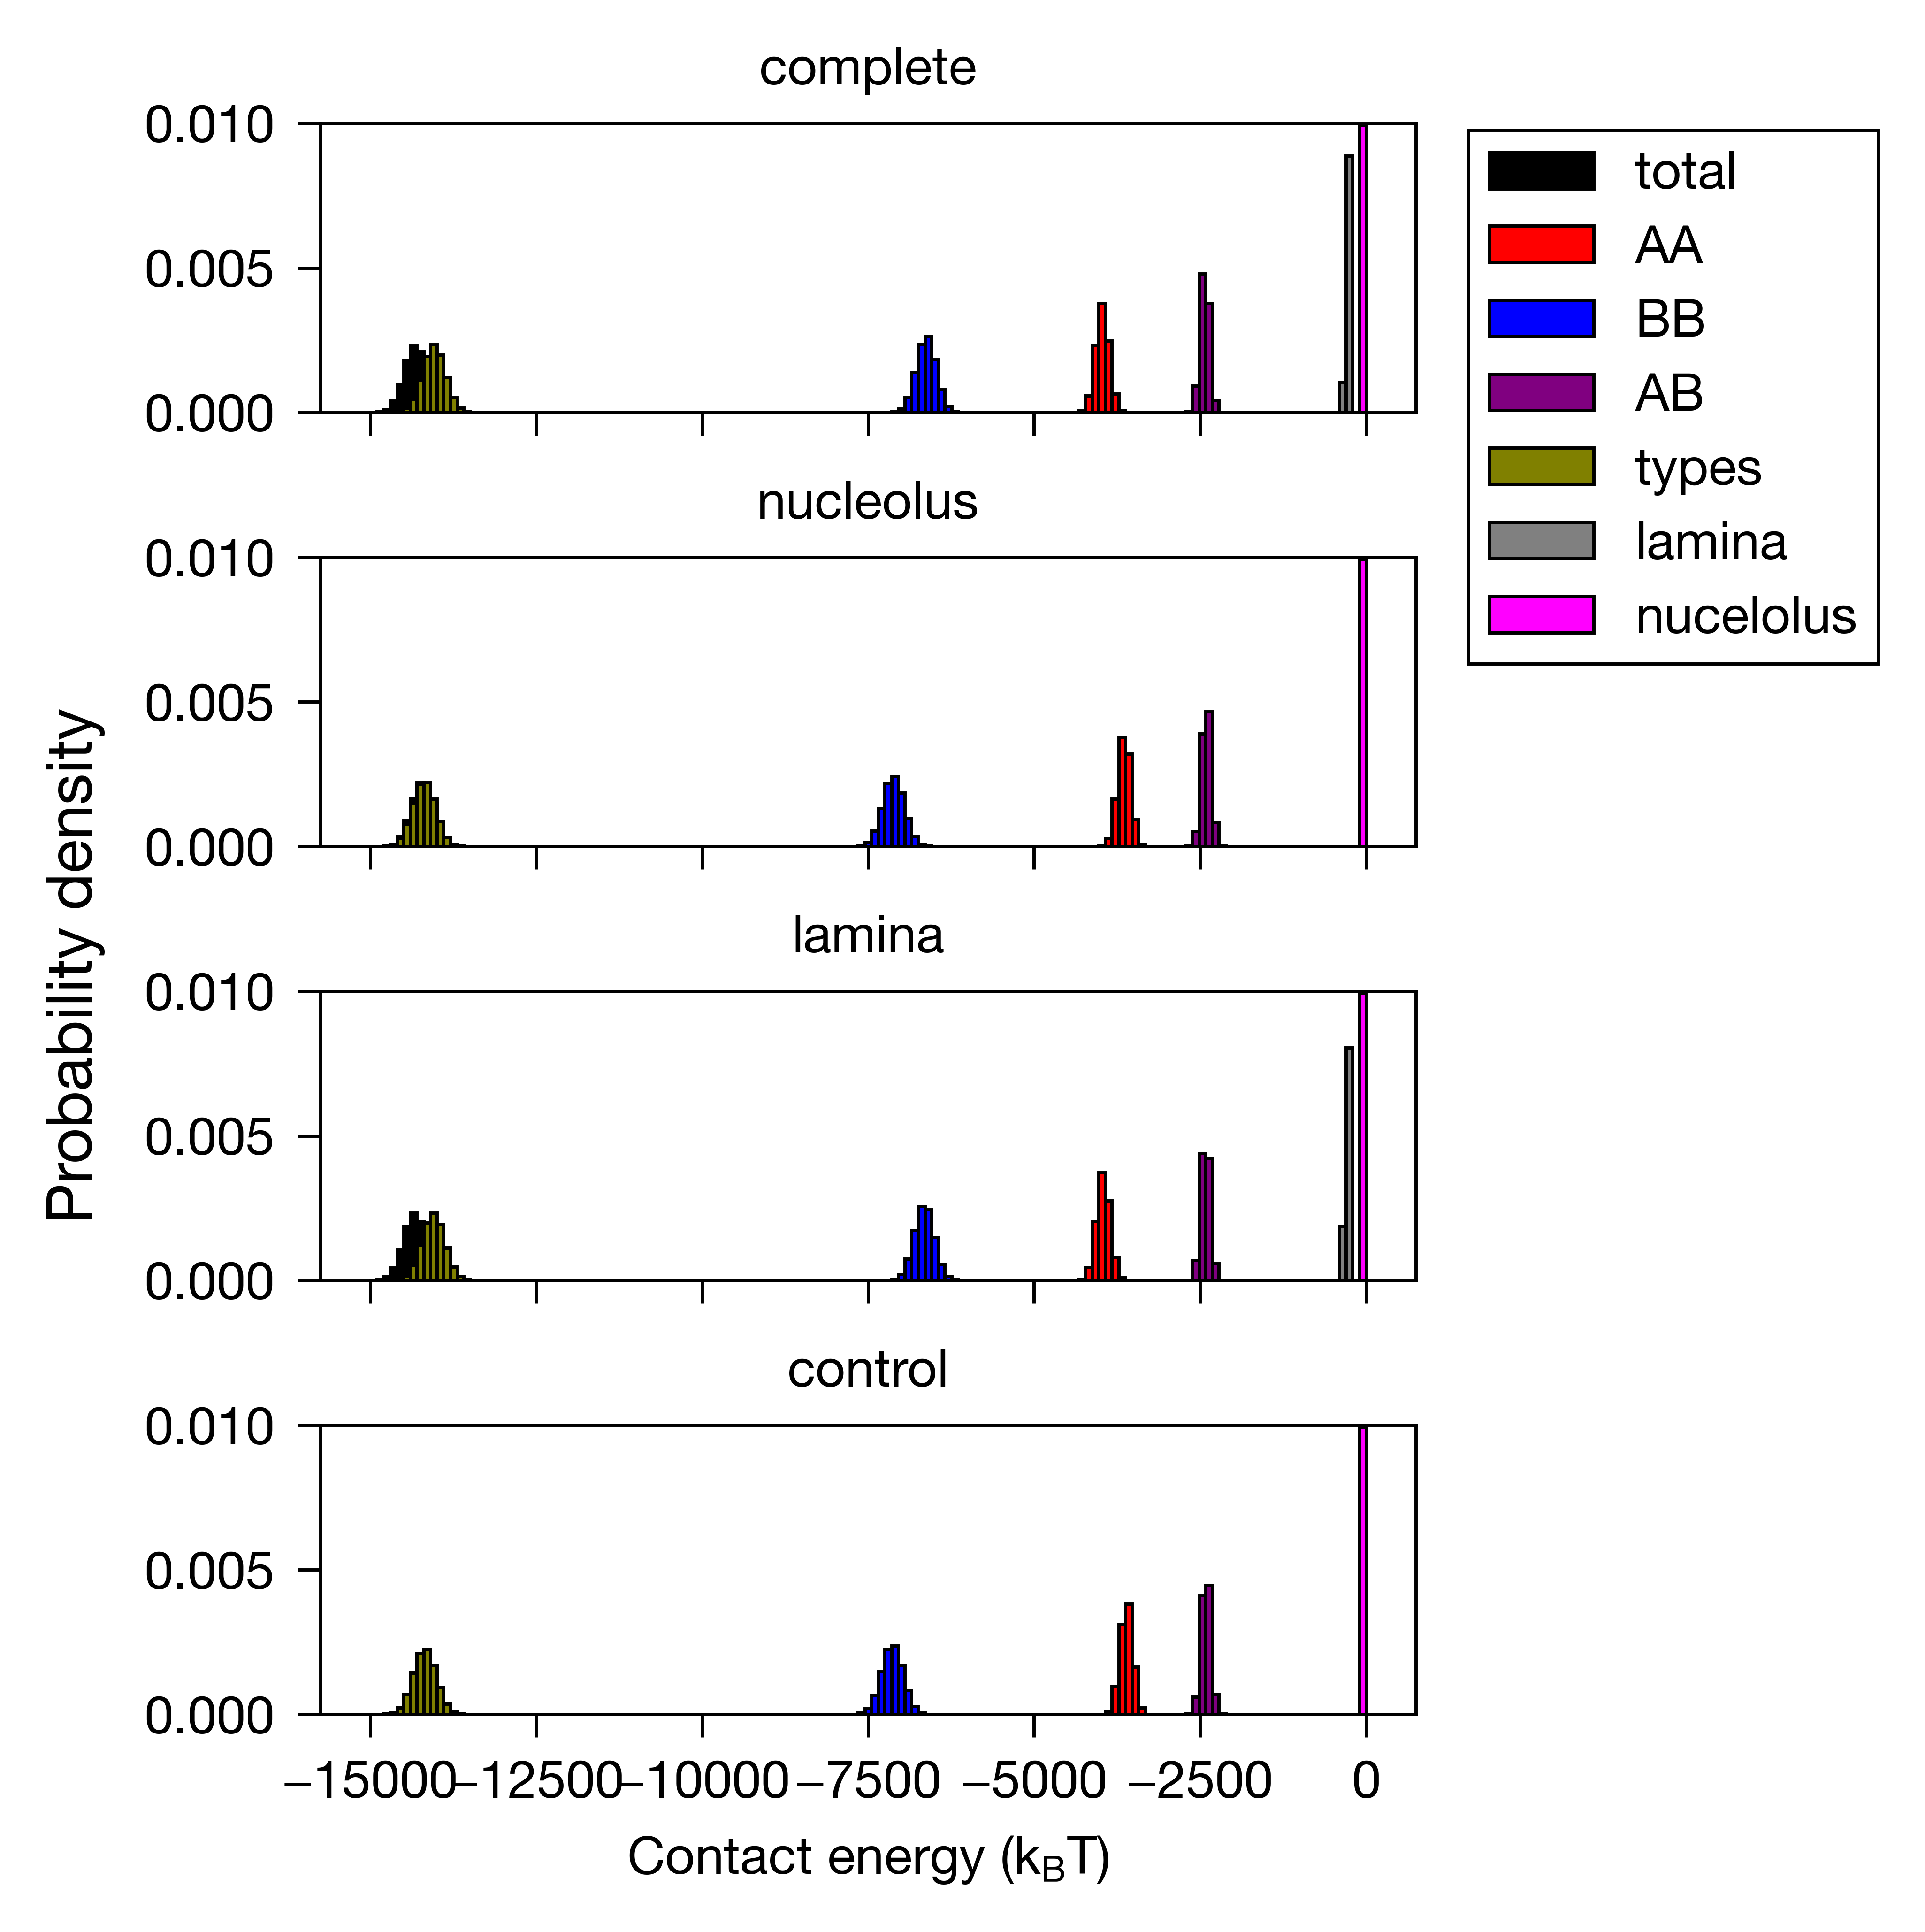

In [10]:
conditions = [
    "complete",
    "nucleolus",
    "lamina",
    "control",
    # "nuclear-bodies",
    # "isolation",
]

fig, ax = plt.subplots(
    len(conditions),
    1,
    figsize=(
        3,
        1 * len(conditions),
    ),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

bins = np.linspace(-15000, -0, 150)

for i, condition in enumerate(conditions):
    ax[i].set_title(condition)

    ax[i].hist(
        energies_per_condition[condition]["all"],
        bins=bins,
        density=True,
        # histtype="step",
        label="total",
        color="black",
    )
    ax[i].hist(
        energies_per_condition[condition]["AA"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AA",
        color="red",
    )
    ax[i].hist(
        energies_per_condition[condition]["BB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="BB",
        color="blue",
    )
    ax[i].hist(
        energies_per_condition[condition]["AB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AB",
        color="purple",
    )
    ax[i].hist(
        np.sum(
            [
                energies_per_condition[condition][key]
                for key in ["AA", "AB", "BB", "AN", "BN", "NN"]
            ],
            axis=0,
        ),
        bins=bins,
        density=True,
        # histtype="step",
        label="types",
        color="olive",
    )
    ax[i].hist(
        energies_per_condition[condition]["lamina"],
        bins=bins,
        density=True,
        # histtype="step",
        label="lamina",
        color="gray",
    )
    ax[i].hist(
        energies_per_condition[condition]["nucleolus"],
        bins=bins,
        density=True,
        # histtype="step",
        label="nucelolus",
        color="magenta",
    )

    ax[i].set_ylim(0, 0.010)

fig.supylabel("Probability density")
ax[-1].set_xlabel("Contact energy ($k_B$T)")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.005, 0.959),
    loc="upper left",
    fontsize=8,
    ncol=1,
)

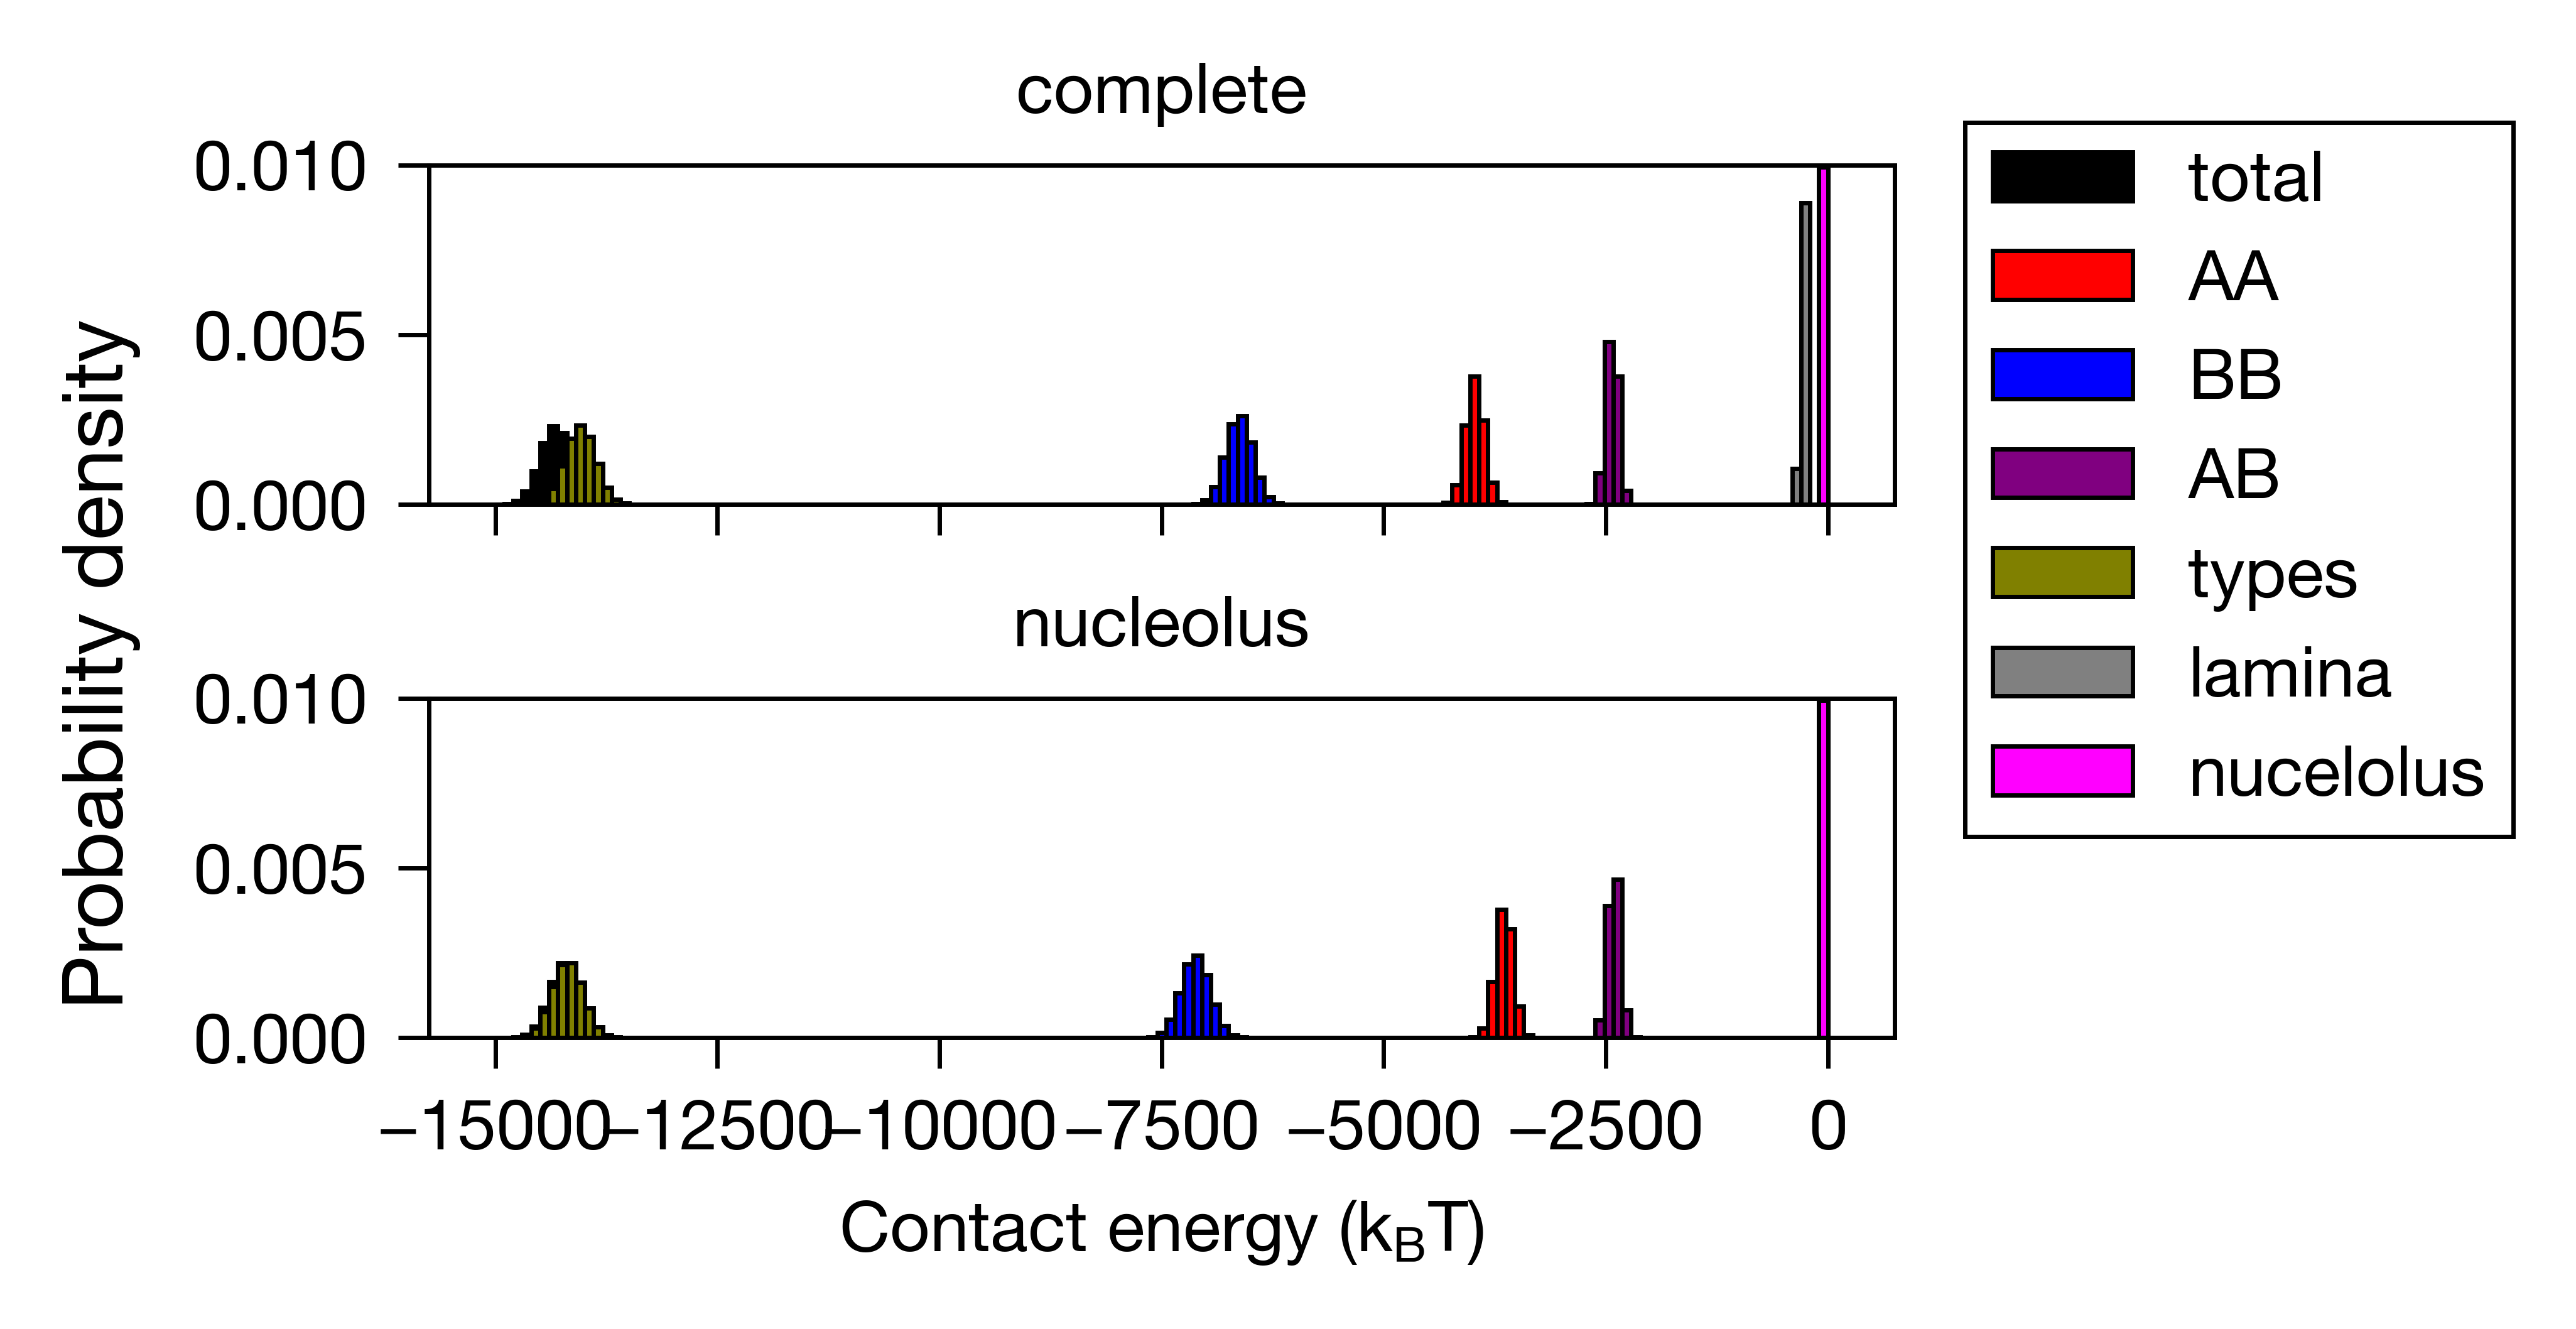

In [11]:
conditions = [
    "complete",
    "nucleolus",
    # "lamina",
    # "control",
    # "nuclear-bodies",
    # "isolation",
]

fig, ax = plt.subplots(
    len(conditions),
    1,
    figsize=(
        3,
        1 * len(conditions),
    ),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

bins = np.linspace(-15000, -0, 150)

for i, condition in enumerate(conditions):
    ax[i].set_title(condition)

    ax[i].hist(
        energies_per_condition[condition]["all"],
        bins=bins,
        density=True,
        # histtype="step",
        label="total",
        color="black",
    )
    ax[i].hist(
        energies_per_condition[condition]["AA"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AA",
        color="red",
    )
    ax[i].hist(
        energies_per_condition[condition]["BB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="BB",
        color="blue",
    )
    ax[i].hist(
        energies_per_condition[condition]["AB"],
        bins=bins,
        density=True,
        # histtype="step",
        label="AB",
        color="purple",
    )
    ax[i].hist(
        np.sum(
            [
                energies_per_condition[condition][key]
                for key in ["AA", "AB", "BB", "AN", "BN", "NN"]
            ],
            axis=0,
        ),
        bins=bins,
        density=True,
        # histtype="step",
        label="types",
        color="olive",
    )
    ax[i].hist(
        energies_per_condition[condition]["lamina"],
        bins=bins,
        density=True,
        # histtype="step",
        label="lamina",
        color="gray",
    )
    ax[i].hist(
        energies_per_condition[condition]["nucleolus"],
        bins=bins,
        density=True,
        # histtype="step",
        label="nucelolus",
        color="magenta",
    )

    ax[i].set_ylim(0, 0.010)

fig.supylabel("Probability density")
ax[-1].set_xlabel("Contact energy ($k_B$T)")
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    bbox_to_anchor=(1.005, 0.959),
    loc="upper left",
    fontsize=8,
    ncol=1,
)